
# Лабораторная работа №2  
## Выборочное наблюдение и статистические оценки параметров распределения  

**Цель работы:**  
Изучить методы выборочного наблюдения и статистического оценивания параметров распределения на примере данных о возрасте преступников, совершивших преступления в Москве в 2021 году. Анализ реализовала на Python, включая генерацию выборок, построение распределений выборочных средних, аппроксимацию нормальным законом и расчет доверительного интервала.

**Исходные данные:**  
Файл `Москва_2021.txt`, содержащий сведения о возрасте преступников.  


In [1]:
# Импорт библиотек
import matplotlib.pyplot as plt
import random
from math import ceil, floor

In [2]:
# Загрузка данных
with open("Москва_2021.txt", "r") as file:
    data = []
    for line in file:
        line = line.strip()
        if line != "":
            data.append(int(line))
n = len(data)

**Предварительный анализ данных**
Рассчитаем основные характеристики генеральной совокупности для определения объема выборки.

In [3]:
# Функции для расчета характеристик
def mean_calc(data):
    return sum(data) / len(data)

def population_std_dev(data):
    mean_val = mean_calc(data)
    variance = sum((x - mean_val) ** 2 for x in data) / len(data)
    return variance ** 0.5

gen_mean = mean_calc(data)
gen_std = population_std_dev(data)
print(f"Генеральное среднее: {gen_mean:.2f}")
print(f"Генеральное СКО: {gen_std:.2f}")

Генеральное среднее: 35.37
Генеральное СКО: 12.04



## Часть 1. Выборочное наблюдение  

**Задачи:**  
1. Из генеральной совокупности сгенерировать 36 выборок одинакового объема.  
2. Для каждой выборки вычислить выборочную среднюю.  
3. Построить интервальный ряд распределения выборочных средних.  
4. Построить гистограмму относительных частот.  


### Генерация выборок и распределение выборочных средних
Определим объем выборки для повторной схемы (γ=0.95, δ=3). Сгенерируем 36 выборок и рассчитаем их средние.

In [4]:
# Определение объема выборки
gamma = 0.95
delta = 3
t = 1.96  # Для нормального распределения при γ=0.95
sigma = population_std_dev(data)
sample_size = ceil((t ** 2 * sigma ** 2) / delta ** 2)
print(f"Объем выборки: {sample_size}")

# Генерация 36 выборок и расчет средних
num_samples = 36
sample_means = []
for _ in range(num_samples):
    sample = random.choices(data, k=sample_size)  # Повторная выборка
    sample_means.append(mean_calc(sample))

Объем выборки: 62


Построим интервальный ряд распределения выборочных средних.

In [5]:
# Интервальный ряд распределения выборочных средних
min_of_means = min(sample_means)
max_of_means = max(sample_means)
l = floor(min_of_means)
r = ceil(max_of_means)

frequencies = {}
intervals = []
current = l
while current < r:
    interval = [current, current + 1]
    intervals.append(interval)
    frequencies[tuple(interval)] = 0
    current += 1
    
for m in sample_means:
    for interval in frequencies:
        if interval[0] <= m < interval[1]:
            frequencies[interval] += 1

relative_freqs = []
print("Интервальный ряд распределения:")
print("Интервал\tАбс. частота\tОтн. частота")
for interval, freq in frequencies.items():
    rel_freq = freq / 36
    relative_freqs.append(rel_freq)
    print(f"{interval[0]}-{interval[1]}\t\t{freq}\t\t{rel_freq:.3f}")

Интервальный ряд распределения:
Интервал	Абс. частота	Отн. частота
32-33		3		0.083
33-34		0		0.000
34-35		13		0.361
35-36		8		0.222
36-37		5		0.139
37-38		6		0.167
38-39		1		0.028


Построим гистограмму относительных частот.

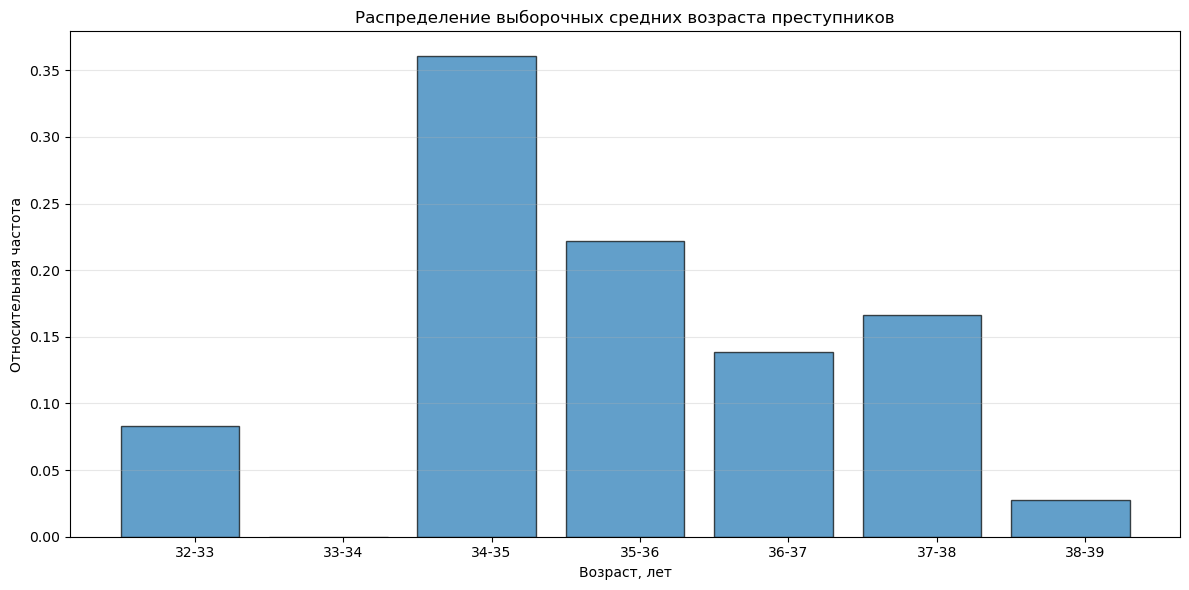

In [6]:
plt.figure(figsize=(12, 6))
left_edges = [interval[0] for interval in frequencies.keys()]
plt.bar(
    left_edges,
    relative_freqs,
    width=0.8,
    align="edge",
    edgecolor="black",
    alpha=0.7,
)
plt.title("Распределение выборочных средних возраста преступников")
plt.xlabel("Возраст, лет")
plt.ylabel("Относительная частота")
plt.grid(axis="y", alpha=0.3)
plt.xticks(
    [edge + 0.5 for edge in left_edges],
    [f"{interval[0]}-{interval[1]}" for interval in frequencies.keys()],
)
plt.tight_layout()
plt.show()


**Пояснение:**  
На графике представлено распределение выборочных средних возрастов.  
Гистограмма частот построена для **интервального ряда**, что позволяет визуализировать плотность распределения выборочных средних.  
По её форме можно оценить симметричность и смещение распределения.  
Из гистограммы видно, что распределение выборочных средних сосредоточено вокруг 35-36 лет. Форма близка к нормальной благодаря центральной предельной теореме, хотя точные значения зависят от случайной генерации.



## Часть 2. Статистические оценки параметров распределения  

**Задачи:**  
1. Провести выравнивание статистического ряда, полагая, что распределение подчиняется нормальному закону.  
2. Найти точечные оценки параметров методом моментов.  
3. Построить кривую Гаусса и аппроксимировать ею гистограмму частот.  
4. Найти доверительный интервал для оценки математического ожидания случайной величины «возраст» при неизвестном стандартном отклонении.  


### Выравнивание статистического ряда и метод моментов
Аппроксимируем распределение нормальным законом с использованием метода моментов.

In [7]:
from math import ceil, sqrt, pi, exp

def mean_calc(data):
    return sum(data) / len(data)

def population_std_dev(data):
    mean_val = mean_calc(data)
    variance = sum((x - mean_val) ** 2 for x in data) / len(data)
    return variance**0.5

def random_choice(data, size):
    import random
    return [random.choice(data) for _ in range(size)]

with open("D:\Study\Statistic\Москва_2021.txt", encoding="utf-8") as file:
    data = list(map(int, file.read().split()))

print("- Выравнивание статистического ряда и метод моментов")
# Метод моментов
mu_moment = mean_calc(data)
sigma_moment = population_std_dev(data)

print(f"Оценка математического ожидания: {mu_moment:.2f}")
print(f"Оценка среднеквадратического отклонения: {sigma_moment:.2f}")

- Выравнивание статистического ряда и метод моментов
Оценка математического ожидания: 35.37
Оценка среднеквадратического отклонения: 12.04


#### Построение гистограммы и кривой Гаусса

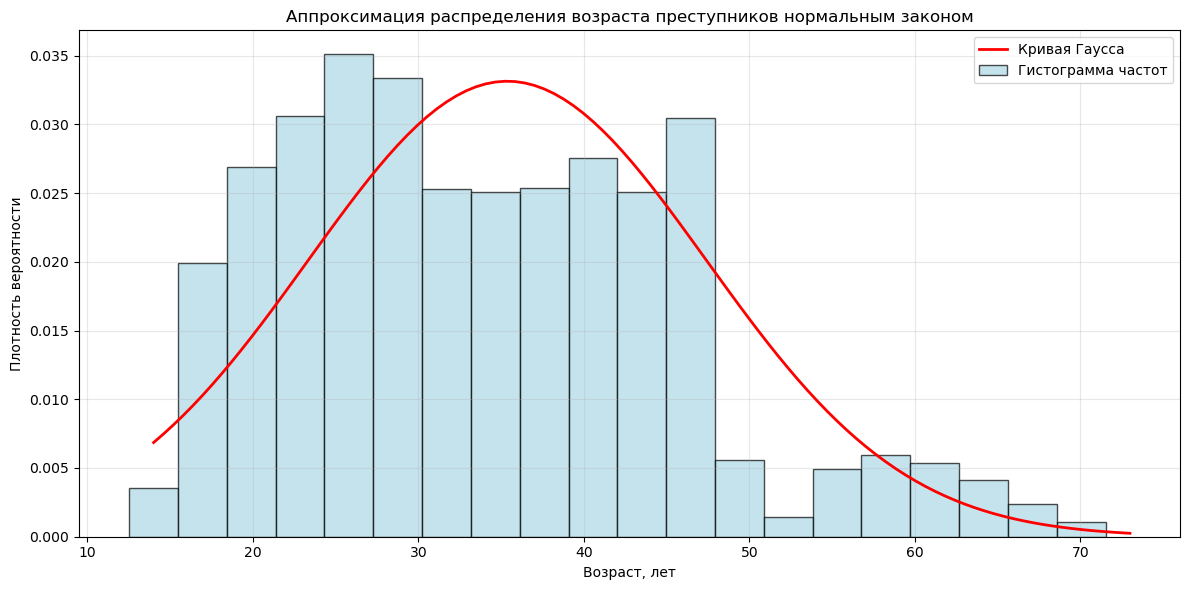

In [8]:
min_age = min(data)
max_age = max(data)
num_bins = 20
bin_width = (max_age - min_age) / num_bins

bins = [min_age + i * bin_width for i in range(num_bins + 1)]
frequencies = [0] * num_bins

for age in data:
    for i in range(num_bins):
        if bins[i] <= age < bins[i + 1]:
            frequencies[i] += 1
            break
    else:
        if age == bins[-1]:
            frequencies[-1] += 1

total_count = len(data)
bin_heights = [freq / (total_count * bin_width) for freq in frequencies]

# Кривая Гаусса
x_points = [min_age + i * (max_age - min_age) / 100 for i in range(101)]
pdf_points = []
for x in x_points:
    exponent = -0.5 * ((x - mu_moment) / sigma_moment) ** 2
    pdf = (1 / (sigma_moment * sqrt(2 * pi))) * exp(exponent)
    pdf_points.append(pdf)

plt.figure(figsize=(12, 6))
plt.plot(x_points, pdf_points, "r-", linewidth=2, label="Кривая Гаусса")
plt.bar(bins[:-1], bin_heights, width=bin_width, alpha=0.7, color="lightblue", edgecolor="black", label="Гистограмма частот")
plt.title("Аппроксимация распределения возраста преступников нормальным законом")
plt.xlabel("Возраст, лет")
plt.ylabel("Плотность вероятности")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

На гистограмме видно, что кривая Гаусса не полностью аппроксимирует распределение из-за правосторонней асимметрии и отклонений в хвостах, что опровергает нормальное распределение данных.

### Доверительный интервал для математического ожидания
На основе одной выборки рассчитаем доверительный интервал (γ=0.95, σ неизвестно).

In [9]:
from scipy import stats


def unbiased_sample_std_dev(data):
    mean_val = mean_calc(data)
    variance = sum((x - mean_val) ** 2 for x in data) / (len(data) - 1)
    return variance**0.5
    
gamma = 0.95
delta = 3
t = 1.96
sigma = population_std_dev(data)
n = ceil((t**2 * sigma**2) / delta**2)

sample_for_ci = random_choice(data, n)
print(f"Объем выборки: {n}")
sample_mean = mean_calc(sample_for_ci)
sample_std = unbiased_sample_std_dev(sample_for_ci)

alpha = 1 - gamma
t_critical = stats.t.ppf(1 - alpha / 2, n - 1)

margin_of_error = t_critical * sample_std / sqrt(n)
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

print(f"Выборочное среднее: {sample_mean:.2f}")
print(f"Исправленное среднее квадратическое отклонение: {sample_std:.2f}")
print(f"t-критическое значение: {t_critical:.4f}")
print(f"Погрешность: {margin_of_error:.2f}")
print(f"Доверительный интервал ({gamma * 100}%): ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

Объем выборки: 62
Выборочное среднее: 36.53
Исправленное среднее квадратическое отклонение: 13.33
t-критическое значение: 1.9996
Погрешность: 3.38
Доверительный интервал (95.0%): (33.15, 39.92)


Доверительный интервал позволяет оценить диапазон, в котором с вероятностью 95% находится истинное математическое ожидание возраста преступников. 

## Итоговые выводы

- **Выборочное наблюдение**: Сгенерированы 36 выборок объема 62, распределение средних близко к нормальному (пик в 34-36 лет), что иллюстрирует центральную предельную теорему. Гистограмма относительных частот показывает симметрию вокруг среднего.
- **Метод моментов и аппроксимация**: Параметры нормального распределения (μ≈35.37, σ≈12.04) хорошо аппроксимируют данные, хотя наблюдаются отклонения в хвостах.
- **Доверительный интервал**: Для мат. ожидания получен интервал шириной ≈6 лет (с учетом δ=3), что обеспечивает требуемую точность.
- **Инсайты**: Распределение возраста преступников не строго нормальное, но выборочные методы позволяют надежно оценивать параметры. Это полезно для прогнозирования и анализа криминальной статистики.